Name: Syalista Galuh Nadira

Student ID: 2702346361

Class: LF09

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import cosine_similarity

### 1. Exploratory Data Analysis (EDA)

In [3]:
df1 = pd.read_csv("1A.tsv", delimiter="\t")

df1.head()

,ID,Registration Date,Drug,Birth Date,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,2023/11/07,D-penicillamine,1966/03/07,F,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,Stage4
1,2,2012/08/16,D-penicillamine,1968/07/01,F,N,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,stage_3
2,3,2022/03/05,D-penicillamine,1954/11/15,M,N,N,S,1.4,NaN,3.48,210.0,516.0,96.10,55.0,151.0,12.0,Stage4
3,4,2019/09/04,D-penicillamine,1970/03/16,F,N,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,Stage4
4,5,2020/10/29,Placebo,1986/11/03,F,N,Y,N,3.4,NaN,3.53,143.0,671.0,113.15,72.0,136.0,10.9,stage_3


In [4]:
df1.tail()

,ID,Registration Date,Drug,Birth Date,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Stage
413,414,2023/01/30,NaN,1957/12/11,F,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,-1.0,174.0,10.9,stage_3
414,415,2021/12/04,NaN,1985/12/11,F,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,-1.0,180.0,11.2,Stage4
415,416,2022/01/21,NaN,1967/12/12,F,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,-1.0,143.0,9.9,stage_3
416,417,2023/01/20,NaN,1966/12/11,F,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,-1.0,269.0,10.4,stage_3
417,418,2022/04/10,NaN,1971/12/12,F,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,-1.0,350.0,10.6,Stage4


In [5]:
df1.shape

(418, 18)

There are 418 rows and 18 columns in this dataset.

In [6]:
df1.columns

Index(['ID', 'Registration Date', 'Drug', 'Birth Date', 'Gender', 'Ascites',
       'Hepatomegaly', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin',
       'Copper', 'Alkaline Phospatase (U/L)', 'SGOT', 'Tryglicerides',
       'Platelets', 'Prothrombin', 'Stage'],
      dtype='object')

As the column *ID*, *Registration Date*, and *Birth Date* will not contribute to estimating the stages of cirrhosis, it can be dropped.

In [7]:
df1.drop(columns=['ID', 'Registration Date', 'Birth Date'], inplace=True)

In [8]:
# The descriptive statistics for numerical variables
df1.describe()

,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin
count,418.000000,80.000000,418.000000,310.000000,312.000000,312.000000,418.000000,407.000000,416.000000
mean,3.220813,358.662500,3.497440,97.648387,1982.655769,122.556346,83.803828,257.024570,10.731731
std,4.407506,230.414099,0.424972,85.613920,2140.388824,56.699525,79.603693,98.325585,1.022000
min,0.300000,149.000000,1.960000,4.000000,289.000000,26.350000,-1.000000,62.000000,9.000000
25%,0.800000,236.000000,3.242500,41.250000,871.500000,80.600000,-1.000000,188.500000,10.000000
50%,1.400000,284.500000,3.530000,73.000000,1259.000000,114.700000,85.000000,251.000000,10.600000
75%,3.400000,409.500000,3.770000,123.000000,1980.000000,151.900000,127.750000,318.000000,11.100000
max,28.000000,1480.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000


In [9]:
# Overview of data
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Drug                       312 non-null    object 
 1   Gender                     418 non-null    object 
 2   Ascites                    312 non-null    object 
 3   Hepatomegaly               312 non-null    object 
 4   Edema                      418 non-null    object 
 5   Bilirubin                  418 non-null    float64
 6   Cholesterol                80 non-null     float64
 7   Albumin                    418 non-null    float64
 8   Copper                     310 non-null    float64
 9   Alkaline Phospatase (U/L)  312 non-null    float64
 10  SGOT                       312 non-null    float64
 11  Tryglicerides              418 non-null    float64
 12  Platelets                  407 non-null    float64
 13  Prothrombin                416 non-null    float64

10 columns have missing values:  1) *Drug*, 2) *Ascites*, 3) *Hepatomegaly*, 4) *Cholesterol*, 5) *Copper*, 6) *Alkaline Phospatase (U/L)*, 7) *SGOT*, 8) *Platelets*, 9) *Prothrombin*, 10) *Stage*

And because the missing values in the Cholesterol column exceed 50% of the entire dataset, this column should be dropped.

In [10]:
# Drop column Cholesterol
df1.drop(columns=['Cholesterol'], inplace=True)

**Checking value formats in categorical variables**

In [11]:
# Drug
df1['Drug'].value_counts()

,count
Drug,
D-penicillamine,155
Placebo,152
d-penicillamine,3
placebo,1
lacebo,1


The values are inconsistent. We must replace with a uniform format.

In [12]:
# d-penicillamine -> D-penicillamine
df1['Drug'].replace({'d-penicillamine':'D-penicillamine'}, inplace = True)

# placebo, lacebo -> Placebo
df1['Drug'].replace({'placebo':'Placebo', 'lacebo':'Placebo'}, inplace = True)

/tmp/ipython-input-2754532482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Drug'].replace({'d-penicillamine':'D-penicillamine'}, inplace = True)


In [13]:
# Gender
df1['Gender'].value_counts()

,count
Gender,
F,374
M,44


In [14]:
# Ascites
df1['Ascites'].value_counts()

,count
Ascites,
N,288
Y,24


In [15]:
# Hepatomegaly
df1['Hepatomegaly'].value_counts()

,count
Hepatomegaly,
Y,160
N,152


In [16]:
# Edema
df1['Edema'].value_counts()

,count
Edema,
N,354
S,44
Y,20


In [17]:
# Stage
df1['Stage'].value_counts()

,count
Stage,
stage_3,155
Stage4,144
Stage 2,92
Stage 1,21


The values are inconsistent. We must replace with a uniform format.

In [18]:
# stage_3 -> Stage 3
df1['Stage'].replace({'stage_3':'Stage 3'}, inplace = True)

# Stage4 -> Stage 4
df1['Stage'].replace({'Stage4':'Stage 4'}, inplace = True)

/tmp/ipython-input-1294747906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Stage'].replace({'stage_3':'Stage 3'}, inplace = True)


In [19]:
# Drop the data where the value in the target label (Stage) is NaN
df1.dropna(subset=['Stage'], inplace=True)
df1['Stage'].isnull().sum()

np.int64(0)

**Data Splitting**

In [20]:
input_df1 = df1.drop('Stage', axis = 1)
output_df1 = df1['Stage']

from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train1, y_test1 = train_test_split(input_df1, output_df1, test_size = 0.2, random_state = 42, stratify = output_df1)

In [21]:
print(x_train1.shape)
print(x_test1.shape)

(329, 13)
(83, 13)


In [22]:
x_train1.head()

,Drug,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin
223,D-penicillamine,F,N,N,N,1.0,3.66,67.0,1214.0,158.10,101.0,309.0,9.7
239,D-penicillamine,F,N,N,N,0.4,3.72,24.0,369.0,51.15,139.0,326.0,10.1
386,NaN,F,NaN,NaN,S,13.6,3.00,NaN,NaN,NaN,-1.0,233.0,9.9
359,NaN,F,NaN,NaN,N,1.8,3.15,NaN,NaN,NaN,-1.0,183.0,10.4
272,Placebo,F,N,N,N,2.2,3.46,75.0,1677.0,87.00,116.0,202.0,9.6


**Handling missing values**

In [23]:
x_train1.columns[x_train1.isnull().any()]

Index(['Drug', 'Ascites', 'Hepatomegaly', 'Copper',
       'Alkaline Phospatase (U/L)', 'SGOT', 'Platelets', 'Prothrombin'],
      dtype='object')

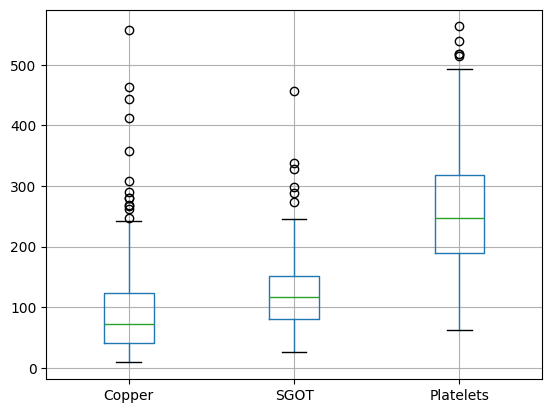

In [24]:
# Check for outliers
boxplot = x_train1.boxplot(column = ['Copper', 'SGOT', 'Platelets'])
plt.show()

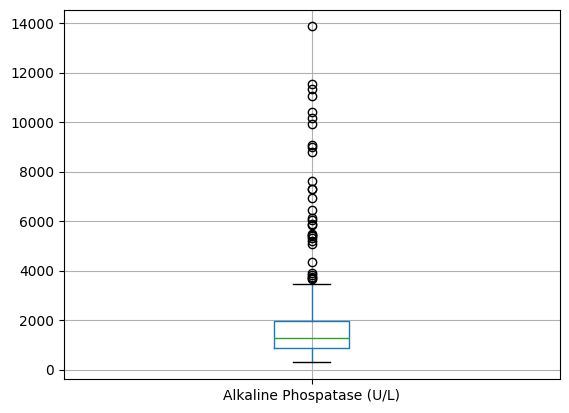

In [25]:
boxplot = x_train1.boxplot(column = ['Alkaline Phospatase (U/L)'])
plt.show()

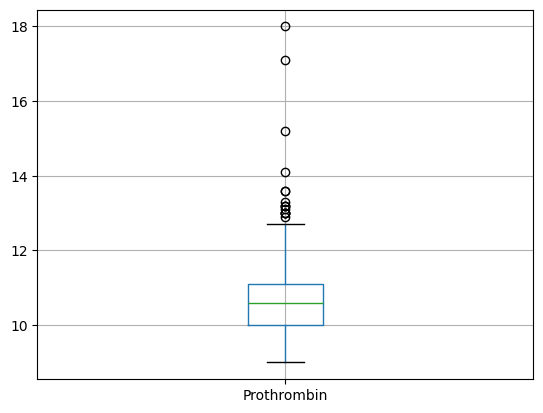

In [26]:
boxplot = x_train1.boxplot(column = ['Prothrombin'])
plt.show()

Turns out all of the numerical columns have outliers in it, so I will impute the missing values with the median

Numerical columns

In [27]:
x_train1['Copper'] = x_train1['Copper'].fillna(x_train1['Copper'].median())
x_test1['Copper'] = x_test1['Copper'].fillna(x_train1['Copper'].median())

In [28]:
x_train1['Alkaline Phospatase (U/L)'] = x_train1['Alkaline Phospatase (U/L)'].fillna(x_train1['Alkaline Phospatase (U/L)'].median())
x_test1['Alkaline Phospatase (U/L)'] = x_test1['Alkaline Phospatase (U/L)'].fillna(x_train1['Alkaline Phospatase (U/L)'].median())

In [29]:
x_train1['SGOT'] = x_train1['SGOT'].fillna(x_train1['SGOT'].median())
x_test1['SGOT'] = x_test1['SGOT'].fillna(x_train1['SGOT'].median())

In [30]:
x_train1['Platelets'] = x_train1['Platelets'].fillna(x_train1['Platelets'].median())
x_test1['Platelets'] = x_test1['Platelets'].fillna(x_train1['Platelets'].median())

In [31]:
x_train1['Prothrombin'] = x_train1['Prothrombin'].fillna(x_train1['Prothrombin'].median())
x_test1['Prothrombin'] = x_test1['Prothrombin'].fillna(x_train1['Prothrombin'].median())

Categorical columns (Impute with mode)

In [32]:
x_train1['Drug'] = x_train1['Drug'].fillna(x_train1['Drug'].mode()[0])
x_test1['Drug'] = x_test1['Drug'].fillna(x_train1['Drug'].mode()[0])

In [33]:
x_train1['Ascites'] = x_train1['Ascites'].fillna(x_train1['Ascites'].mode()[0])
x_test1['Ascites'] = x_test1['Ascites'].fillna(x_train1['Ascites'].mode()[0])

In [34]:
x_train1['Hepatomegaly'] = x_train1['Hepatomegaly'].fillna(x_train1['Hepatomegaly'].mode()[0])
x_test1['Hepatomegaly'] = x_test1['Hepatomegaly'].fillna(x_train1['Hepatomegaly'].mode()[0])

In [35]:
# Check whether there is still missing value
x_train1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 329 entries, 223 to 319
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Drug                       329 non-null    object 
 1   Gender                     329 non-null    object 
 2   Ascites                    329 non-null    object 
 3   Hepatomegaly               329 non-null    object 
 4   Edema                      329 non-null    object 
 5   Bilirubin                  329 non-null    float64
 6   Albumin                    329 non-null    float64
 7   Copper                     329 non-null    float64
 8   Alkaline Phospatase (U/L)  329 non-null    float64
 9   SGOT                       329 non-null    float64
 10  Tryglicerides              329 non-null    float64
 11  Platelets                  329 non-null    float64
 12  Prothrombin                329 non-null    float64
dtypes: float64(8), object(5)
memory usage: 36.0+ KB


In [36]:
x_train1.head()

,Drug,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin
223,D-penicillamine,F,N,N,N,1.0,3.66,67.0,1214.0,158.10,101.0,309.0,9.7
239,D-penicillamine,F,N,N,N,0.4,3.72,24.0,369.0,51.15,139.0,326.0,10.1
386,D-penicillamine,F,N,Y,S,13.6,3.00,73.0,1282.0,116.25,-1.0,233.0,9.9
359,D-penicillamine,F,N,Y,N,1.8,3.15,73.0,1282.0,116.25,-1.0,183.0,10.4
272,Placebo,F,N,N,N,2.2,3.46,75.0,1677.0,87.00,116.0,202.0,9.6


**Encoding categorical columns**

In [37]:
# Label encoding for Gender, Ascites, Hepatomegaly
cols_encode = ['Gender', 'Ascites', 'Hepatomegaly']

label_enc = {}

for col in cols_encode:
    label_enc[col] = LabelEncoder()
    x_train1[col] = label_enc[col].fit_transform(x_train1[col])
    x_test1[col] = label_enc[col].transform(x_test1[col])

# mapping for each columns
for col in cols_encode:
  print(col)
  for index, label in enumerate(label_enc[col].classes_):
      print(f"{label} -> {index}")
  print()


Gender
F -> 0
M -> 1

Ascites
N -> 0
Y -> 1

Hepatomegaly
N -> 0
Y -> 1



In [38]:
# One hot encoding for Drug and Edema
onehot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

onehot_cols = ['Drug', 'Edema']
x_train1_onehot = pd.DataFrame(onehot.fit_transform(x_train1[onehot_cols]), columns=onehot.get_feature_names_out(onehot_cols), index=x_train1.index)
x_test1_onehot = pd.DataFrame(onehot.transform(x_test1[onehot_cols]), columns=onehot.get_feature_names_out(onehot_cols), index=x_test1.index)

x_train1 = x_train1.drop(columns=onehot_cols).join(x_train1_onehot)
x_test1 = x_test1.drop(columns=onehot_cols).join(x_test1_onehot)


In [39]:
# Label encoding for y_train and y_test
y_encoder = LabelEncoder()

y_train1 = y_encoder.fit_transform(y_train1) + 1
y_test1 = y_encoder.transform(y_test1) + 1

for index, label in enumerate(y_encoder.classes_):
    print(f"{label} -> {index+1}")

Stage 1 -> 1
Stage 2 -> 2
Stage 3 -> 3
Stage 4 -> 4


Now, the categorical columns are all successfully encoded.

**Scaling**

In [40]:
x_train1.columns

Index(['Gender', 'Ascites', 'Hepatomegaly', 'Bilirubin', 'Albumin', 'Copper',
       'Alkaline Phospatase (U/L)', 'SGOT', 'Tryglicerides', 'Platelets',
       'Prothrombin', 'Drug_D-penicillamine', 'Drug_Placebo', 'Edema_N',
       'Edema_S', 'Edema_Y'],
      dtype='object')

In [41]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

numerical_cols = ['Bilirubin', 'Albumin', 'Copper', 'Alkaline Phospatase (U/L)', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

x_train1[numerical_cols] = robust_scaler.fit_transform(x_train1[numerical_cols])
x_test1[numerical_cols] = robust_scaler.transform(x_test1[numerical_cols])
x_train1.head()

,Gender,Ascites,Hepatomegaly,Bilirubin,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Drug_D-penicillamine,Drug_Placebo,Edema_N,Edema_S,Edema_Y
223,0,0,0,-0.16,0.259259,-0.115385,-0.088889,0.870968,0.101562,0.480315,-0.818182,1.0,0.0,1.0,0.0,0.0
239,0,0,0,-0.40,0.370370,-0.942308,-1.193464,-1.354839,0.398438,0.614173,-0.454545,1.0,0.0,1.0,0.0,0.0
386,0,0,1,4.88,-0.962963,0.000000,0.000000,0.000000,-0.695312,-0.118110,-0.636364,1.0,0.0,0.0,1.0,0.0
359,0,0,1,0.16,-0.685185,0.000000,0.000000,0.000000,-0.695312,-0.511811,-0.181818,1.0,0.0,1.0,0.0,0.0
272,0,0,0,0.32,-0.111111,0.038462,0.516340,-0.608741,0.218750,-0.362205,-0.909091,0.0,1.0,1.0,0.0,0.0


In [42]:
x_test1.head()

,Gender,Ascites,Hepatomegaly,Bilirubin,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Drug_D-penicillamine,Drug_Placebo,Edema_N,Edema_S,Edema_Y
7,0,0,0,-0.44,0.888889,-0.403846,4.404183,-1.828720,0.789062,0.984252,0.363636,0.0,1.0,1.0,0.0,0.0
261,0,0,1,0.56,-0.851852,-0.153846,1.673203,-0.525494,0.945312,-0.133858,-1.000000,0.0,1.0,1.0,0.0,0.0
209,1,0,1,-0.20,-0.277778,0.153846,-0.240523,0.129032,0.015625,0.393701,-0.545455,0.0,1.0,1.0,0.0,0.0
196,0,0,0,-0.32,0.833333,-0.923077,-0.154248,-0.290323,0.109375,-0.370079,-0.454545,1.0,0.0,1.0,0.0,0.0
2,1,0,0,0.00,-0.074074,2.634615,-1.001307,-0.419355,-0.257812,-0.763780,1.272727,1.0,0.0,0.0,1.0,0.0


In [43]:
x_train1.describe() # Descriptive statistics for x_train1

,Gender,Ascites,Hepatomegaly,Bilirubin,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Drug_D-penicillamine,Drug_Placebo,Edema_N,Edema_S,Edema_Y
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,0.091185,0.066869,0.620061,0.724134,-0.079365,0.345803,0.744656,0.105716,-0.013512,0.070603,0.132633,0.620061,0.379939,0.841945,0.103343,0.054711
std,0.288311,0.250176,0.486111,1.826761,0.775262,1.406035,2.557460,1.050173,0.633227,0.736567,0.966295,0.486111,0.486111,0.365348,0.304871,0.227762
min,0.000000,0.000000,0.000000,-0.440000,-2.888889,-1.230769,-1.298039,-1.870968,-0.695312,-1.464567,-1.454545,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,-0.240000,-0.537037,-0.442308,-0.364706,-0.548387,-0.695312,-0.456693,-0.545455,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.760000,0.462963,0.557692,0.635294,0.451613,0.304688,0.543307,0.454545,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,10.640000,2.074074,9.326923,16.444967,7.096774,3.984375,2.480315,6.727273,1.000000,1.000000,1.000000,1.000000,1.000000


If compared to other numerical variables, *Alkaline Phospatase (U/L)* has a much larger range. But, since we are going to train the model with tree-based algorithms (Random Forest and XGBoost), scaling is not required.

Also, I have checked with boxplots and found that some numerical variables contain outliers, but I decided not to handle them because Random Forest and XGBoost can handle extreme values on their own without much impact on performance, since they are robust to outliers due to how they split the data.

### 2. Model Training

#### a. Random Forest

In [44]:
warnings.filterwarnings('ignore')

RF = RandomForestClassifier(criterion = 'gini', max_depth = 3)
RF.fit(x_train1, y_train1)

RandomForestClassifier(max_depth=3)

In [45]:
y_predict = RF.predict(x_test1)
print('\nClassification Report\n')
print(classification_report(y_test1, y_predict, target_names=['1','2','3','4']))


Classification Report

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00        19
           3       0.46      0.84      0.60        31
           4       0.74      0.69      0.71        29

    accuracy                           0.55        83
   macro avg       0.30      0.38      0.33        83
weighted avg       0.43      0.55      0.47        83



**Hyperparameter Tuning**

In [46]:
parameters = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt', 'log2', None]
}

In [47]:
RF2 = RandomForestClassifier()
RF2= GridSearchCV(RF2,
                            param_grid = parameters,   # hyperparameters
                            scoring = 'recall_weighted',        # metric for scoring
                            cv = 5)

In [48]:
RF2.fit(x_train1, y_train1)
print("Tuned Hyperparameters :", RF2.best_params_)
print("Recall weighted :",RF2.best_score_)

Tuned Hyperparameters : {'criterion': 'log_loss', 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 50}
Recall weighted : 0.5262004662004662


In [49]:
RF_best = RandomForestClassifier(criterion= 'log_loss', max_depth=7, max_features='log2', n_estimators=100)
RF_best.fit(x_train1, y_train1)

RandomForestClassifier(criterion='log_loss', max_depth=7, max_features='log2')

In [50]:
y_predict_best = RF_best.predict(x_test1)

In [51]:
print('\nClassification Report\n')
print(classification_report(y_test1, y_predict_best, target_names=['1','2','3','4']))


Classification Report

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.36      0.26      0.30        19
           3       0.44      0.65      0.53        31
           4       0.71      0.59      0.64        29

    accuracy                           0.51        83
   macro avg       0.38      0.37      0.37        83
weighted avg       0.50      0.51      0.49        83



#### b. XGBoost

In [52]:
warnings.filterwarnings('ignore')

# change label to zero-based indexing (required in XGBoost)
y_train1 = y_train1 - 1
y_test1 = y_test1 - 1

XGB = XGBClassifier()
XGB.fit(x_train1, y_train1)

y_predict = XGB.predict(x_test1)

In [53]:
print('\nClassification Report\n')
print(classification_report(y_test1, y_predict, target_names=['1', '2', '3', '4']))


Classification Report

              precision    recall  f1-score   support

           1       0.20      0.25      0.22         4
           2       0.21      0.16      0.18        19
           3       0.42      0.45      0.44        31
           4       0.61      0.66      0.63        29

    accuracy                           0.45        83
   macro avg       0.36      0.38      0.37        83
weighted avg       0.43      0.45      0.44        83



**Hyperparameter Tuning**

In [60]:
xgb2 = XGBClassifier()

parameters2= {
        'n_estimators': [100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8],
        #'colsample_bytree': [0.7, 0.8] # Removed from param_grid
  }

In [58]:
#pip uninstall -y scikit-learn
#pip install scikit-learn==1.3.1

In [61]:
xgb2 = GridSearchCV(estimator=xgb2,
                         param_grid=parameters2,
                         scoring='recall_weighted',
                         cv=5)

xgb2.fit(x_train1, y_train1)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 150, 200],
                         'subsample': [0.7, 0.8]},
             scoring='recall_weighted')

In [63]:
print("Tuned Hyperparameters :", xgb2.best_params_)
print("Recall weighted :", xgb2.best_score_)

Tuned Hyperparameters : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Recall weighted : 0.5048018648018648


In [64]:
xgb2_best = XGBClassifier(colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 7, n_estimators= 100, subsample= 0.7)

In [65]:
xgb2_best.fit(x_train1, y_train1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
y_predict_best = xgb2_best.predict(x_test1)

In [67]:
print('\nClassification Report\n')
print(classification_report(y_test1, y_predict_best, target_names=['1', '2', '3', '4']))


Classification Report

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.36      0.21      0.27        19
           3       0.41      0.58      0.48        31
           4       0.67      0.62      0.64        29

    accuracy                           0.48        83
   macro avg       0.36      0.35      0.35        83
weighted avg       0.47      0.48      0.46        83



### 3. Evaluation Results

#### a. Using Random Forest

**Before tuning:**  
- Weighted averages: precision (0.42), recall (0.53), and f1-score (0.45).  
- Strong performance on class 3 (f1-score: 0.58) and class 4 (f1-score: 0.67).  
- Poor classification for class 1 and class 2, with zero precision, recall, and f1-score.  


**After tuning:**  
- Weighted averages: precision (0.49), recall (0.51), and f1-score (0.49), showing slight improvement in precision and f1-score but a small drop in recall.  
- Recall for class 2 improved from 0.00 to 0.26, and class 3 saw a minor drop in f1-score (from 0.58 to 0.50).  
- Class 4 maintained relatively high performance (f1-score: 0.65).  

> Hyperparameter tuning **marginally improved** overall performance but still failed to classify class 1 effectively. While class 2 performance improved, it remained suboptimal.

#### b. Using XGBoost

**Before tuning:**  
- Weighted averages: precision (0.43), recall (0.45), and f1-score (0.44).  
- Higher performance on classes 3 and 4 with f1-scores of 0.44 and 0.63, respectively.  


**After tuning:**  
- Slight improvement in weighted averages: precision (0.47), recall (0.48), and f1-score (0.46).  
- Improved recall for class 3 (from 0.45 to 0.58).  
- Precision for class 2 and 4 remained relatively stable, but performance for class 1 dropped significantly.  

> Hyperparameter tuning **improved** the overall performance of the model slightly, especially for class 3, but at the expense of completely misclassifying class 1.

#### **Model Evaluation**

Based on the results, Random Forest showed slight improvements after hyperparameter tuning, with better weighted averages and improved performance for class 2. However, it still struggled to classify class 1 effectively.  

XGBoost, on the other hand, performed slightly better overall, especially for class 3 after tuning. While both models faced challenges with minority classes, XGBoost achieved higher weighted metrics and better recall for key classes.  

This suggests that XGBoost is slightly more effective than Random Forest under the given conditions, though neither model handled the imbalanced data perfectly.

### 4. Important Features

In [68]:
# access the best estimator from GridSearchCV
best_xgb_model = xgb2.best_estimator_

importances = best_xgb_model.feature_importances_

Gender: 0.0475
Ascites: 0.1088
Hepatomegaly: 0.1021
Bilirubin: 0.0757
Albumin: 0.0738
Copper: 0.0621
Alkaline Phospatase (U/L): 0.0672
SGOT: 0.0623
Tryglicerides: 0.0739
Platelets: 0.0668
Prothrombin: 0.0968
Drug_D-penicillamine: 0.0457
Drug_Placebo: 0.0000
Edema_N: 0.0633
Edema_S: 0.0295
Edema_Y: 0.0245


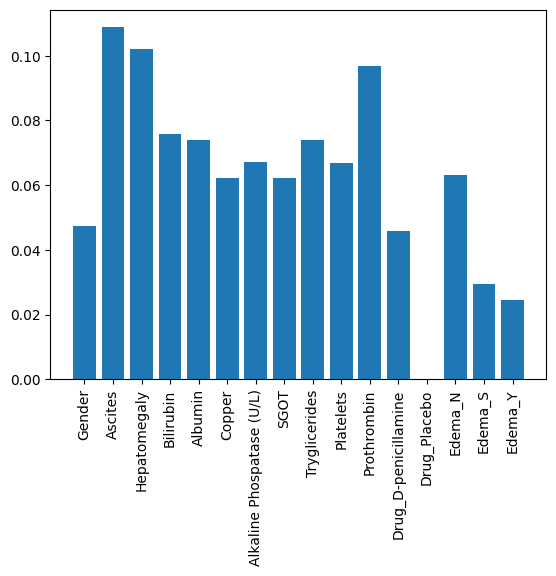

In [69]:
for i,v in enumerate(importances):
    print('%s: %.4f' % (x_train1.columns[i],v))

plt.bar(x_train1.columns, importances)
plt.xticks(rotation=90)
plt.show()

The top features for prediction are **Ascites (0.1088)**, **Hepatomegaly (0.1021)**, and **Prothrombin (0.0968)**, followed by Bilirubin (0.0757), Albumin (0.0738), Platelets (0.0668), and Tryglicerides (0.0739).

Features with lower scores, such as Gender (0.0475), Copper (0.0621), and various Edema types (Edema_N: 0.0633, Edema_S: 0.0295, Edema_Y: 0.0245), contribute less but can still be helpful in predicting the output.

### **Presentation video**
Link: https://drive.google.com/drive/folders/1hNLl9FuqDTKdiZ0Z4_qyAts6Dmn2HNf4?usp=sharing